In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
from sklearn.impute import SimpleImputer,KNNImputer,MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

In [3]:
url='https://raw.githubusercontent.com/sachin365123/CSV-files-for-Data-Science-and-Machine-Learning/main/Loan%20Approval%20Prediction.csv'
df=pd.read_csv(url)

In [4]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


#  removing the null values or droping them

In [5]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
df_removed = df.dropna()
df_removed.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

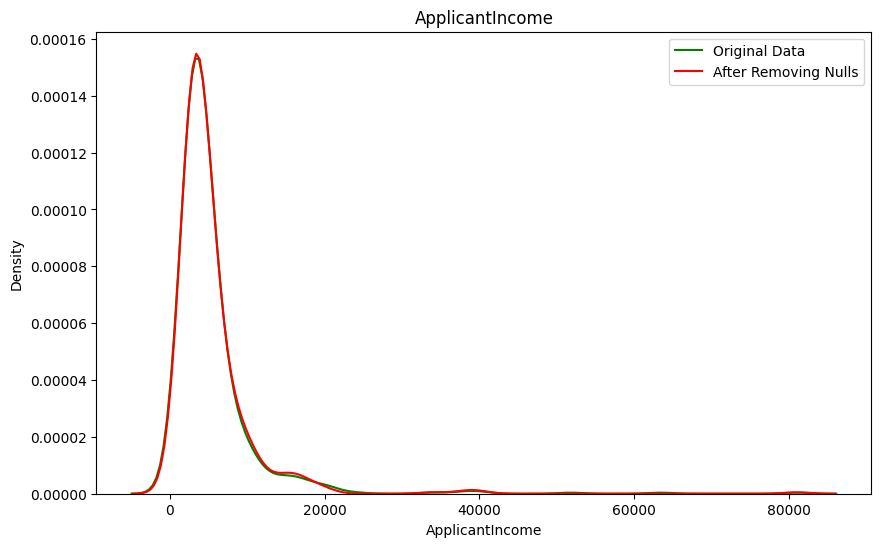

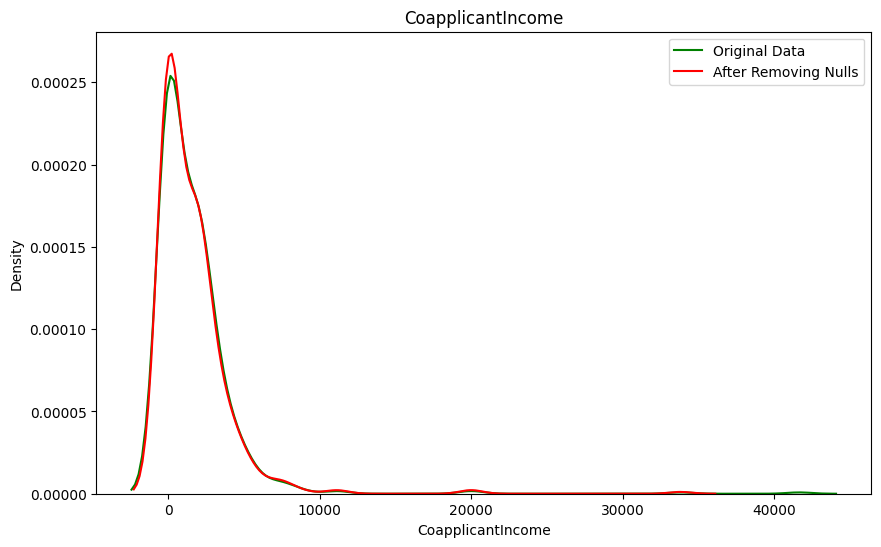

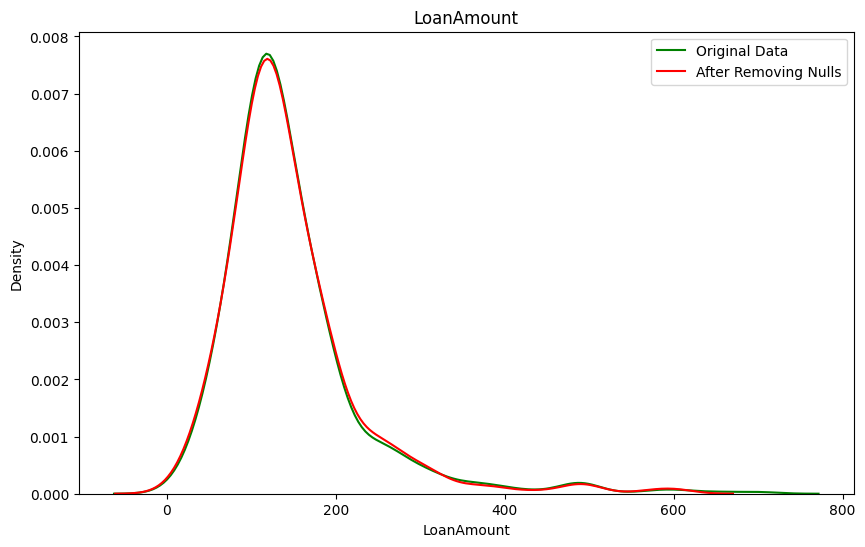

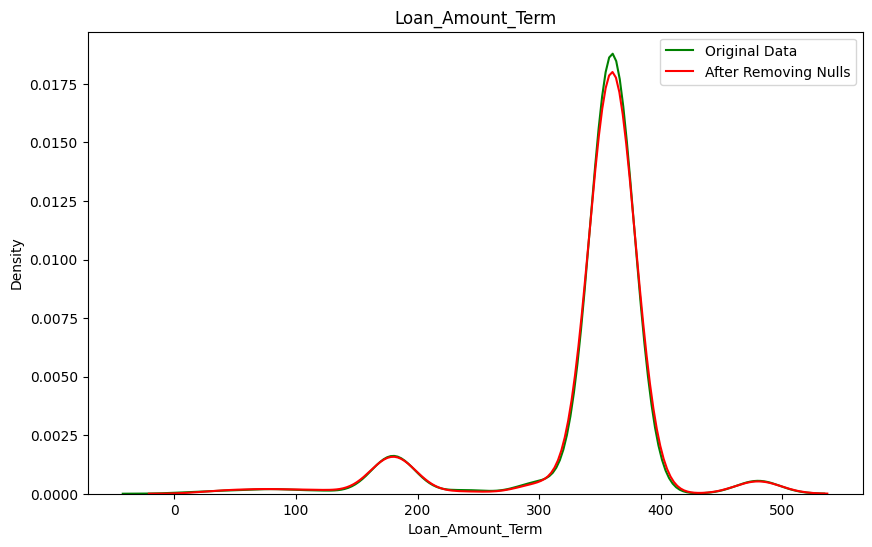

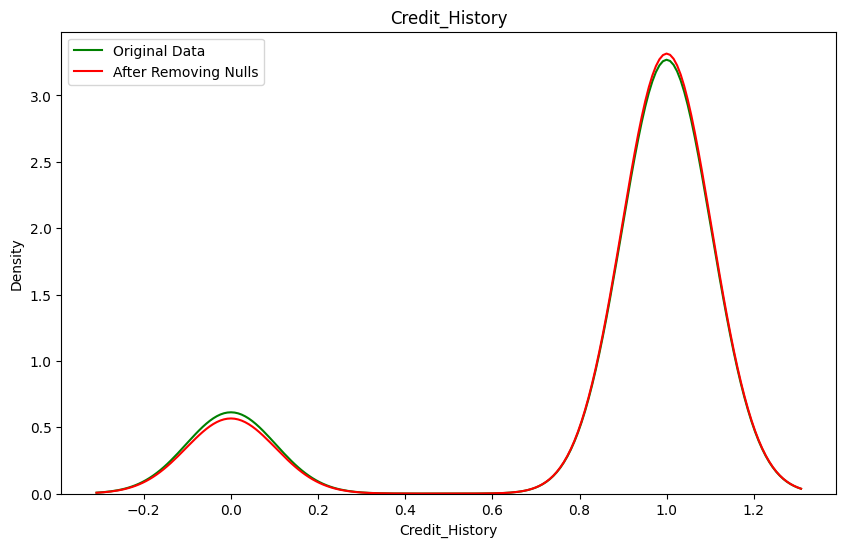

In [7]:
for col in df.select_dtypes(include="number"):
    fig,(ax1)=plt.subplots(ncols=1,figsize=(10,6))
    sns.kdeplot(df[col], ax=ax1, color="green")
    sns.kdeplot(df_removed[col], ax=ax1, color="red")

    ax1.set_title(col)
    ax1.legend(["Original Data", "After Removing Nulls"])

    plt.show()

In [8]:
# This catches most categorical/text columns
for col in df.select_dtypes(include=["object", "category"]).columns:
    temp=pd.concat([
        df[col].value_counts()/len(df),
        df_removed[col].value_counts()/len(df_removed)
    ],axis=1)
    temp.columns=['original','removed']
    print(temp)
 

          original   removed
Loan_ID                     
LP002990  0.001629  0.002083
LP001002  0.001629       NaN
LP001003  0.001629  0.002083
LP001005  0.001629  0.002083
LP001006  0.001629  0.002083
...            ...       ...
LP001024  0.001629  0.002083
LP001020  0.001629  0.002083
LP001018  0.001629  0.002083
LP001014  0.001629  0.002083
LP001013  0.001629  0.002083

[614 rows x 2 columns]
        original   removed
Gender                    
Male    0.796417  0.820833
Female  0.182410  0.179167
         original   removed
Married                    
Yes      0.648208  0.647917
No       0.346906  0.352083
            original   removed
Dependents                    
0           0.561889  0.570833
1           0.166124  0.166667
2           0.164495  0.177083
3+          0.083062  0.085417
              original   removed
Education                       
Graduate      0.781759  0.797917
Not Graduate  0.218241  0.202083
               original  removed
Self_Employed               

In [9]:
X = df_removed.drop(columns=['Loan_ID','Loan_Status'])
y=df_removed['Loan_Status']
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [10]:
X['Property_Area'].value_counts()

Property_Area
Semiurban    191
Urban        150
Rural        139
Name: count, dtype: int64

In [11]:
tf1=ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[0,1,3,4]),
    ('ordinal',OrdinalEncoder(categories=[['0', '1', '2', '3+'],['Rural','Semiurban','Urban']]),[2,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf1.set_output(transform="pandas")

X_tf1 = tf1.fit_transform(X)
le=LabelEncoder()
y_tf1=le.fit_transform(y)


In [12]:
X_tf1

,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Dependents,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,4583,1508.0,128.0,360.0,1.0
2,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,3000,0.0,66.0,360.0,1.0
3,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,2583,2358.0,120.0,360.0,1.0
4,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,6000,0.0,141.0,360.0,1.0
5,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,2.0,5417,4196.0,267.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2900,0.0,71.0,360.0,1.0
610,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,4106,0.0,40.0,180.0,1.0
611,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,2.0,8072,240.0,253.0,360.0,1.0
612,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,2.0,7583,0.0,187.0,360.0,1.0


In [13]:
from sklearn.preprocessing import StandardScaler
scale=ColumnTransformer([
    ('std',StandardScaler(),[10,11,12,13])
],remainder='passthrough',verbose_feature_names_out=False)
scale.set_output(transform='pandas')
X_scaled=scale.fit_transform(X_tf1)
X_scaled

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Dependents,Property_Area,Credit_History
1,-0.137970,-0.027952,-0.208089,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2,-0.417536,-0.604633,-0.979001,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0
3,-0.491180,0.297100,-0.307562,0.275542,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0
4,0.112280,-0.604633,-0.046446,0.275542,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0
5,0.009319,0.999978,1.520245,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,-0.435196,-0.604633,-0.916831,0.275542,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
610,-0.222210,-0.604633,-1.302286,-2.487549,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,1.0
611,0.478206,-0.512854,1.346168,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,2.0,1.0
612,0.391846,-0.604633,0.525520,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,2.0,1.0


In [14]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y_tf1,test_size=0.2,random_state=42)
x_train

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Dependents,Property_Area,Credit_History
172,-0.325348,-0.604633,-0.792490,-2.487549,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,0.0,1.0
288,-0.219031,-0.604633,-0.369732,0.275542,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
607,-0.243226,-0.065046,0.152499,0.275542,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,2.0,0.0,1.0
55,-0.469105,-0.158355,-0.593545,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,1.0,1.0
461,0.419573,-0.604633,-0.208089,-2.487549,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,0.009319,-0.604633,0.289273,0.275542,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0
350,0.656754,-0.604633,1.035317,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
445,-0.335238,-0.141912,-0.183221,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
558,-0.260887,0.416031,0.214669,0.275542,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0


In [15]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [16]:
y_pred=model.predict(x_test)

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8229166666666666

In [18]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X_scaled, y_tf1, cv=5, scoring='accuracy').mean()

np.float64(0.8020833333333334)

# ohe(drop=first)

In [19]:
tf1=ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'),[0,1,3,4]),
    ('ordinal',OrdinalEncoder(categories=[['0', '1', '2', '3+'],['Rural','Semiurban','Urban']]),[2,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf1.set_output(transform="pandas")

X_tf1 = tf1.fit_transform(X)
le=LabelEncoder()
y_tf1=le.fit_transform(y)

In [20]:
X_tf1

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Dependents,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
1,1.0,1.0,0.0,0.0,1.0,0.0,4583,1508.0,128.0,360.0,1.0
2,1.0,1.0,0.0,1.0,0.0,2.0,3000,0.0,66.0,360.0,1.0
3,1.0,1.0,1.0,0.0,0.0,2.0,2583,2358.0,120.0,360.0,1.0
4,1.0,0.0,0.0,0.0,0.0,2.0,6000,0.0,141.0,360.0,1.0
5,1.0,1.0,0.0,1.0,2.0,2.0,5417,4196.0,267.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,0.0,0.0,2900,0.0,71.0,360.0,1.0
610,1.0,1.0,0.0,0.0,3.0,0.0,4106,0.0,40.0,180.0,1.0
611,1.0,1.0,0.0,0.0,1.0,2.0,8072,240.0,253.0,360.0,1.0
612,1.0,1.0,0.0,0.0,2.0,2.0,7583,0.0,187.0,360.0,1.0


In [21]:
from sklearn.preprocessing import StandardScaler
scale=ColumnTransformer([
    ('std',StandardScaler(),[7,8,9,10])
],remainder='passthrough',verbose_feature_names_out=False)
scale.set_output(transform='pandas')
X_scaled=scale.fit_transform(X_tf1)
X_scaled

,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Dependents,Property_Area,ApplicantIncome
1,-0.027952,-0.208089,0.275542,0.413197,1.0,1.0,0.0,0.0,1.0,0.0,4583
2,-0.604633,-0.979001,0.275542,0.413197,1.0,1.0,0.0,1.0,0.0,2.0,3000
3,0.297100,-0.307562,0.275542,0.413197,1.0,1.0,1.0,0.0,0.0,2.0,2583
4,-0.604633,-0.046446,0.275542,0.413197,1.0,0.0,0.0,0.0,0.0,2.0,6000
5,0.999978,1.520245,0.275542,0.413197,1.0,1.0,0.0,1.0,2.0,2.0,5417
...,...,...,...,...,...,...,...,...,...,...,...
609,-0.604633,-0.916831,0.275542,0.413197,0.0,0.0,0.0,0.0,0.0,0.0,2900
610,-0.604633,-1.302286,-2.487549,0.413197,1.0,1.0,0.0,0.0,3.0,0.0,4106
611,-0.512854,1.346168,0.275542,0.413197,1.0,1.0,0.0,0.0,1.0,2.0,8072
612,-0.604633,0.525520,0.275542,0.413197,1.0,1.0,0.0,0.0,2.0,2.0,7583


In [22]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y_tf1,test_size=0.2,random_state=42)
x_train

,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Dependents,Property_Area,ApplicantIncome
172,-0.604633,-0.792490,-2.487549,0.413197,1.0,1.0,1.0,0.0,3.0,0.0,3522
288,-0.604633,-0.369732,0.275542,0.413197,0.0,0.0,0.0,0.0,0.0,1.0,4124
607,-0.065046,0.152499,0.275542,0.413197,1.0,1.0,1.0,0.0,2.0,0.0,3987
55,-0.158355,-0.593545,0.275542,0.413197,1.0,1.0,0.0,0.0,2.0,1.0,2708
461,-0.604633,-0.208089,-2.487549,0.413197,1.0,1.0,0.0,0.0,3.0,2.0,7740
...,...,...,...,...,...,...,...,...,...,...,...
141,-0.604633,0.289273,0.275542,0.413197,1.0,0.0,0.0,0.0,0.0,2.0,5417
350,-0.604633,1.035317,0.275542,0.413197,1.0,1.0,0.0,0.0,0.0,1.0,9083
445,-0.141912,-0.183221,0.275542,0.413197,1.0,1.0,0.0,1.0,1.0,0.0,3466
558,0.416031,0.214669,0.275542,0.413197,1.0,1.0,0.0,0.0,0.0,1.0,3887


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.8229166666666666

In [24]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X_scaled, y_tf1, cv=5, scoring='accuracy').mean()

np.float64(0.8020833333333334)

# missing value removed less than 5% and other filled with mean,most frequent

In [25]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [26]:
df.isnull().mean()*100


Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [27]:
nul_column = [var for var in df.columns 
              if df[var].isnull().mean() <= 0.05 and df[var].isnull().mean() > 0]
nul_column

['Gender', 'Married', 'Dependents', 'LoanAmount', 'Loan_Amount_Term']

In [28]:
# This keeps ALL columns but drops rows where 'nul_column' has NaNs
df_rem = df.dropna(subset=nul_column)
df_rem

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [29]:
df_rem['Credit_History'].value_counts()

Credit_History
1.0    434
0.0     71
Name: count, dtype: int64

In [30]:
df_rem.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        30
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       48
Property_Area         0
Loan_Status           0
dtype: int64

In [31]:
X = df_rem.drop(columns=['Loan_ID','Loan_Status'])
y=df_rem['Loan_Status']
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [32]:
tf1=ColumnTransformer([
    ('cat',SimpleImputer(strategy='most_frequent'),['Self_Employed','Credit_History'])
],remainder='passthrough',verbose_feature_names_out=False)
tf1.set_output(transform='pandas')
X_tf1=tf1.fit_transform(X)
X_tf1

,Self_Employed,Credit_History,Gender,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area
1,No,1.0,Male,Yes,1,Graduate,4583,1508.0,128.0,360.0,Rural
2,Yes,1.0,Male,Yes,0,Graduate,3000,0.0,66.0,360.0,Urban
3,No,1.0,Male,Yes,0,Not Graduate,2583,2358.0,120.0,360.0,Urban
4,No,1.0,Male,No,0,Graduate,6000,0.0,141.0,360.0,Urban
5,Yes,1.0,Male,Yes,2,Graduate,5417,4196.0,267.0,360.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,No,1.0,Female,No,0,Graduate,2900,0.0,71.0,360.0,Rural
610,No,1.0,Male,Yes,3+,Graduate,4106,0.0,40.0,180.0,Rural
611,No,1.0,Male,Yes,1,Graduate,8072,240.0,253.0,360.0,Urban
612,No,1.0,Male,Yes,2,Graduate,7583,0.0,187.0,360.0,Urban


In [33]:
X_tf1.isnull().sum()

Self_Employed        0
Credit_History       0
Gender               0
Married              0
Dependents           0
Education            0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Property_Area        0
dtype: int64

In [34]:
tf2=ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'),[0,2,3,5]),
    ('ordinal',OrdinalEncoder(categories=[['0', '1', '2', '3+'],['Rural','Semiurban','Urban']]),[4,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf2.set_output(transform="pandas")

X_tf2 = tf2.fit_transform(X_tf1)
le=LabelEncoder()
y_tf2=le.fit_transform(y)

In [35]:
X_tf2

,Self_Employed_Yes,Gender_Male,Married_Yes,Education_Not Graduate,Dependents,Property_Area,Credit_History,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,4583,1508.0,128.0,360.0
2,1.0,1.0,1.0,0.0,0.0,2.0,1.0,3000,0.0,66.0,360.0
3,0.0,1.0,1.0,1.0,0.0,2.0,1.0,2583,2358.0,120.0,360.0
4,0.0,1.0,0.0,0.0,0.0,2.0,1.0,6000,0.0,141.0,360.0
5,1.0,1.0,1.0,0.0,2.0,2.0,1.0,5417,4196.0,267.0,360.0
...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2900,0.0,71.0,360.0
610,0.0,1.0,1.0,0.0,3.0,0.0,1.0,4106,0.0,40.0,180.0
611,0.0,1.0,1.0,0.0,1.0,2.0,1.0,8072,240.0,253.0,360.0
612,0.0,1.0,1.0,0.0,2.0,2.0,1.0,7583,0.0,187.0,360.0


In [36]:
from sklearn.preprocessing import StandardScaler
scale=ColumnTransformer([
    ('std',StandardScaler(),[7,8,9,10])
],remainder='passthrough',verbose_feature_names_out=False)
scale.set_output(transform='pandas')
X_scaled=scale.fit_transform(X_tf2)
X_scaled

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Self_Employed_Yes,Gender_Male,Married_Yes,Education_Not Graduate,Dependents,Property_Area,Credit_History
1,-0.128694,-0.049699,-0.214368,0.279961,0.0,1.0,1.0,0.0,1.0,0.0,1.0
2,-0.394296,-0.545638,-0.952675,0.279961,1.0,1.0,1.0,0.0,0.0,2.0,1.0
3,-0.464262,0.229842,-0.309634,0.279961,0.0,1.0,1.0,1.0,0.0,2.0,1.0
4,0.109057,-0.545638,-0.059562,0.279961,0.0,1.0,0.0,0.0,0.0,2.0,1.0
5,0.011239,0.834309,1.440866,0.279961,1.0,1.0,1.0,0.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
609,-0.411075,-0.545638,-0.893134,0.279961,0.0,0.0,0.0,0.0,0.0,0.0,1.0
610,-0.208727,-0.545638,-1.262287,-2.468292,0.0,1.0,1.0,0.0,3.0,0.0,1.0
611,0.456706,-0.466709,1.274152,0.279961,0.0,1.0,1.0,0.0,1.0,2.0,1.0
612,0.374659,-0.545638,0.488213,0.279961,0.0,1.0,1.0,0.0,2.0,2.0,1.0


In [37]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y_tf2,test_size=0.2,random_state=42)
x_train

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Self_Employed_Yes,Gender_Male,Married_Yes,Education_Not Graduate,Dependents,Property_Area,Credit_History
20,0.387579,-0.545638,-0.500164,0.279961,0.0,1.0,1.0,1.0,0.0,2.0,0.0
365,0.145298,-0.545638,-0.154828,0.279961,0.0,1.0,0.0,1.0,0.0,0.0,1.0
539,0.179023,-0.545638,0.130968,-2.468292,0.0,1.0,1.0,0.0,3.0,0.0,1.0
330,-0.162083,0.044030,-0.345358,0.279961,0.0,1.0,0.0,0.0,1.0,2.0,1.0
531,-0.179364,-0.545638,-0.547797,0.279961,0.0,1.0,1.0,0.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
80,-0.252351,-0.545638,-0.416807,0.279961,0.0,0.0,0.0,0.0,0.0,1.0,1.0
123,-0.401511,-0.545638,-0.774052,0.279961,0.0,1.0,1.0,0.0,2.0,1.0,1.0
300,-0.595637,0.419273,-0.631154,0.279961,0.0,1.0,1.0,1.0,0.0,2.0,0.0
485,-0.569127,0.255494,-0.178644,0.279961,0.0,1.0,1.0,1.0,1.0,0.0,1.0


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.7927927927927928

In [39]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X_scaled, y_tf2, cv=5, scoring='accuracy').mean()

np.float64(0.802964782964783)

# REPLACING WITH mean and most_frequent

In [40]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [41]:
X = df.drop(columns=['Loan_ID','Loan_Status'])
y=df['Loan_Status']
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [42]:
X.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
dtype: int64

In [43]:
tf1=ColumnTransformer([
    ('num',SimpleImputer(),[5,6,7,8]),
    ('cat',SimpleImputer(strategy='most_frequent'),[0,1,2,3,4,9,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf1.set_output(transform='pandas')
X_tf1=tf1.fit_transform(X)
X_tf1

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area
0,5849.0,0.0,146.412162,360.0,Male,No,0,Graduate,No,1.0,Urban
1,4583.0,1508.0,128.000000,360.0,Male,Yes,1,Graduate,No,1.0,Rural
2,3000.0,0.0,66.000000,360.0,Male,Yes,0,Graduate,Yes,1.0,Urban
3,2583.0,2358.0,120.000000,360.0,Male,Yes,0,Not Graduate,No,1.0,Urban
4,6000.0,0.0,141.000000,360.0,Male,No,0,Graduate,No,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,2900.0,0.0,71.000000,360.0,Female,No,0,Graduate,No,1.0,Rural
610,4106.0,0.0,40.000000,180.0,Male,Yes,3+,Graduate,No,1.0,Rural
611,8072.0,240.0,253.000000,360.0,Male,Yes,1,Graduate,No,1.0,Urban
612,7583.0,0.0,187.000000,360.0,Male,Yes,2,Graduate,No,1.0,Urban


In [44]:
X_tf1.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
Credit_History       0
Property_Area        0
dtype: int64

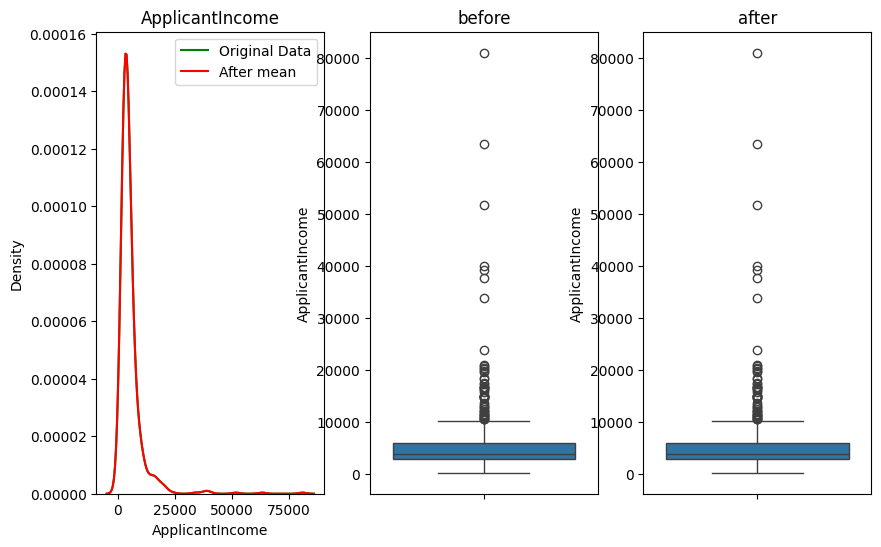

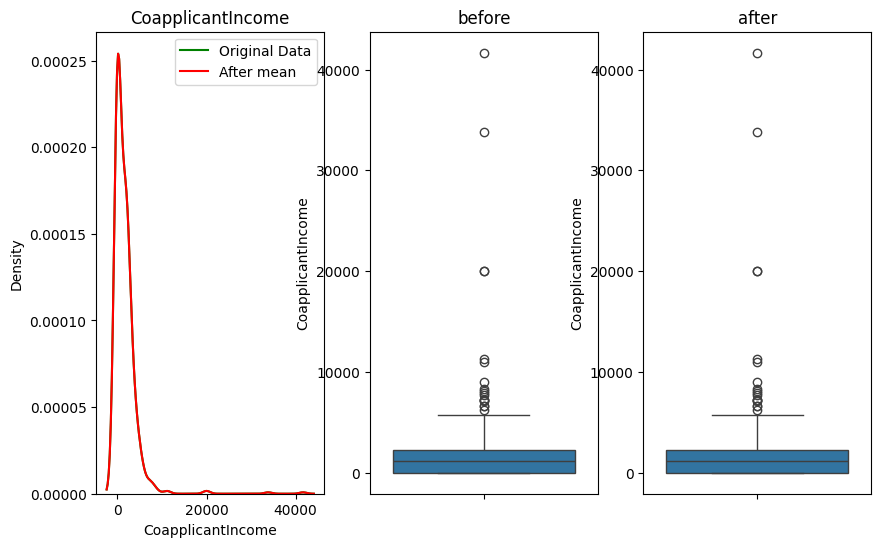

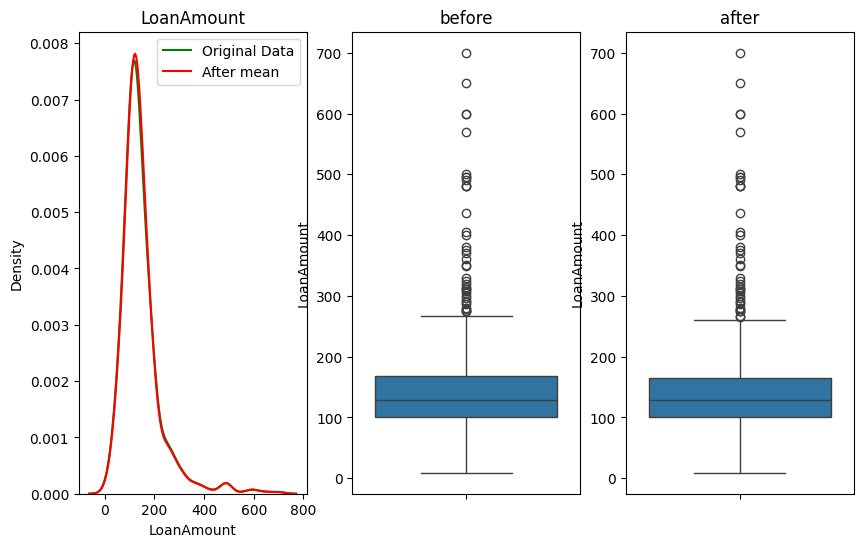

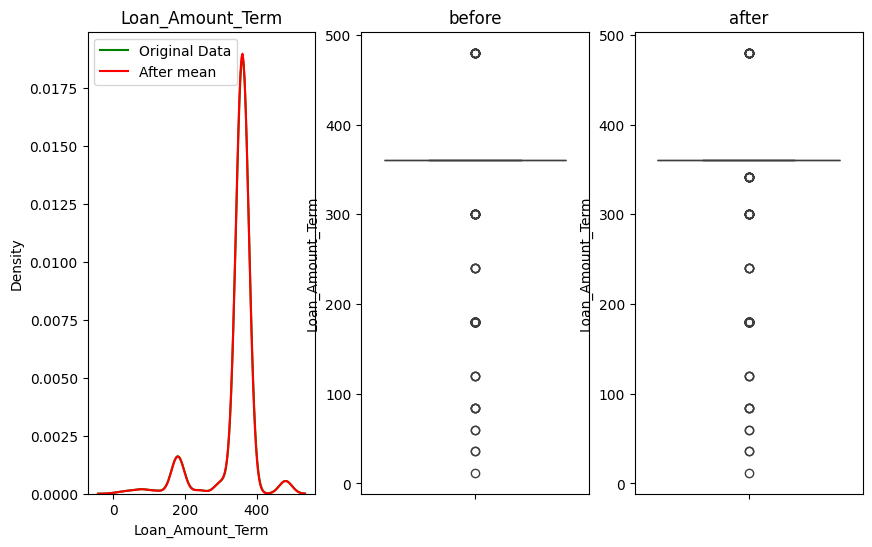

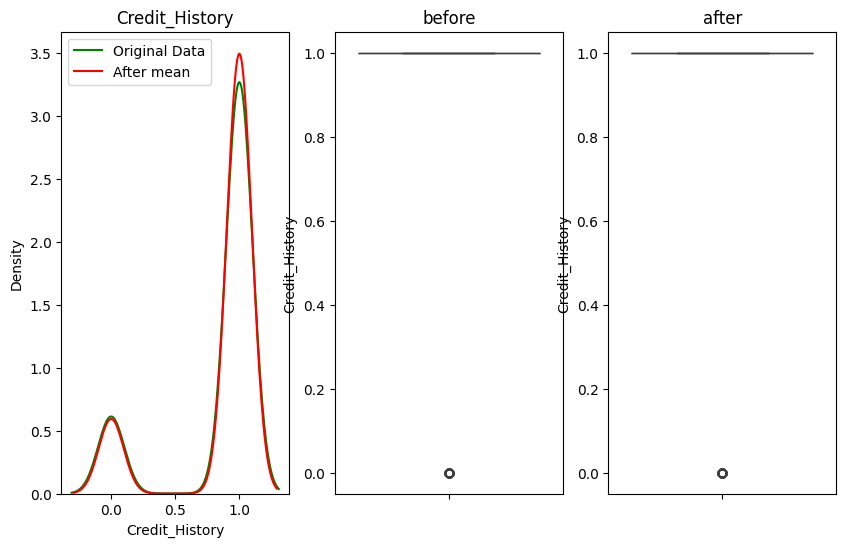

In [45]:
for col in df.select_dtypes(include="number"):
    fig,(ax1,ax2,ax3)=plt.subplots(ncols=3,figsize=(10,6))
    sns.kdeplot(df[col], ax=ax1, color="green")
    sns.kdeplot(X_tf1[col], ax=ax1, color="red")
    sns.boxplot(df[col],ax=ax2)
    sns.boxplot(X_tf1[col],ax=ax3)

    ax1.set_title(col)
    ax2.set_title('before')
    ax3.set_title('after')
    ax1.legend(["Original Data", "After mean"])

    plt.show()

In [46]:
# This catches most categorical/text columns
for col in X.select_dtypes(include=["object", "category"]).columns:
    temp=pd.concat([
        X[col].value_counts()/len(df),
        X_tf1[col].value_counts()/len(df_removed)
    ],axis=1)
    temp.columns=['original','most_frequent']
    print(temp)
 

        original  most_frequent
Gender                         
Male    0.796417       1.045833
Female  0.182410       0.233333
         original  most_frequent
Married                         
Yes      0.648208       0.835417
No       0.346906       0.443750
            original  most_frequent
Dependents                         
0           0.561889       0.750000
1           0.166124       0.212500
2           0.164495       0.210417
3+          0.083062       0.106250
              original  most_frequent
Education                            
Graduate      0.781759       1.000000
Not Graduate  0.218241       0.279167
               original  most_frequent
Self_Employed                         
No             0.814332       1.108333
Yes            0.133550       0.170833
               original  most_frequent
Property_Area                         
Semiurban      0.379479       0.485417
Urban          0.328990       0.420833
Rural          0.291531       0.372917


In [47]:
X_tf1

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area
0,5849.0,0.0,146.412162,360.0,Male,No,0,Graduate,No,1.0,Urban
1,4583.0,1508.0,128.000000,360.0,Male,Yes,1,Graduate,No,1.0,Rural
2,3000.0,0.0,66.000000,360.0,Male,Yes,0,Graduate,Yes,1.0,Urban
3,2583.0,2358.0,120.000000,360.0,Male,Yes,0,Not Graduate,No,1.0,Urban
4,6000.0,0.0,141.000000,360.0,Male,No,0,Graduate,No,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,2900.0,0.0,71.000000,360.0,Female,No,0,Graduate,No,1.0,Rural
610,4106.0,0.0,40.000000,180.0,Male,Yes,3+,Graduate,No,1.0,Rural
611,8072.0,240.0,253.000000,360.0,Male,Yes,1,Graduate,No,1.0,Urban
612,7583.0,0.0,187.000000,360.0,Male,Yes,2,Graduate,No,1.0,Urban


In [48]:
tf2=ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'),[4,5,7,8]),
    ('ordinal',OrdinalEncoder(categories=[['0', '1', '2', '3+'],['Rural','Semiurban','Urban']]),[6,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf2.set_output(transform="pandas")

X_tf2 = tf2.fit_transform(X_tf1)
le=LabelEncoder()
y_tf2=le.fit_transform(y)
X_tf2

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Dependents,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1.0,0.0,0.0,0.0,0.0,2.0,5849.0,0.0,146.412162,360.0,1.0
1,1.0,1.0,0.0,0.0,1.0,0.0,4583.0,1508.0,128.000000,360.0,1.0
2,1.0,1.0,0.0,1.0,0.0,2.0,3000.0,0.0,66.000000,360.0,1.0
3,1.0,1.0,1.0,0.0,0.0,2.0,2583.0,2358.0,120.000000,360.0,1.0
4,1.0,0.0,0.0,0.0,0.0,2.0,6000.0,0.0,141.000000,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,0.0,0.0,2900.0,0.0,71.000000,360.0,1.0
610,1.0,1.0,0.0,0.0,3.0,0.0,4106.0,0.0,40.000000,180.0,1.0
611,1.0,1.0,0.0,0.0,1.0,2.0,8072.0,240.0,253.000000,360.0,1.0
612,1.0,1.0,0.0,0.0,2.0,2.0,7583.0,0.0,187.000000,360.0,1.0


In [49]:
from sklearn.preprocessing import StandardScaler
scale=ColumnTransformer([
    ('std',StandardScaler(),[6,7,8,9])
],remainder='passthrough',verbose_feature_names_out=False)
scale.set_output(transform='pandas')
X_scaled=scale.fit_transform(X_tf2)
X_scaled

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Dependents,Property_Area,Credit_History
0,0.072991,-0.554487,0.000000,0.279851,1.0,0.0,0.0,0.0,0.0,2.0,1.0
1,-0.134412,-0.038732,-0.219273,0.279851,1.0,1.0,0.0,0.0,1.0,0.0,1.0
2,-0.393747,-0.554487,-0.957641,0.279851,1.0,1.0,0.0,1.0,0.0,2.0,1.0
3,-0.462062,0.251980,-0.314547,0.279851,1.0,1.0,1.0,0.0,0.0,2.0,1.0
4,0.097728,-0.554487,-0.064454,0.279851,1.0,0.0,0.0,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
609,-0.410130,-0.554487,-0.898095,0.279851,0.0,0.0,0.0,0.0,0.0,0.0,1.0
610,-0.212557,-0.554487,-1.267279,-2.518655,1.0,1.0,0.0,0.0,3.0,0.0,1.0
611,0.437174,-0.472404,1.269371,0.279851,1.0,1.0,0.0,0.0,1.0,2.0,1.0
612,0.357064,-0.554487,0.483367,0.279851,1.0,1.0,0.0,0.0,2.0,2.0,1.0


In [50]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y_tf2,test_size=0.2,random_state=42)
x_train

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Dependents,Property_Area,Credit_History
83,0.097728,0.215042,1.412281,0.279851,1.0,1.0,0.0,0.0,0.0,1.0,1.0
90,-0.400628,0.437351,-0.183546,0.279851,1.0,1.0,0.0,0.0,0.0,1.0,1.0
227,0.138685,0.025225,0.757277,0.279851,1.0,1.0,0.0,0.0,2.0,1.0,1.0
482,-0.543975,0.522854,-0.219273,0.279851,1.0,1.0,0.0,0.0,0.0,1.0,1.0
464,-0.202727,-0.554487,-0.576548,0.279851,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
71,-0.578051,0.086787,-0.588457,0.279851,1.0,1.0,1.0,1.0,2.0,1.0,1.0
106,0.985170,-0.169381,0.935915,0.279851,1.0,1.0,0.0,0.0,2.0,2.0,1.0
270,-0.354921,-0.554487,-1.386371,0.279851,0.0,0.0,0.0,0.0,0.0,2.0,1.0
435,0.760729,-0.554487,0.000000,-1.585820,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.7886178861788617

In [52]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X_scaled, y_tf2, cv=5, scoring='accuracy').mean()

np.float64(0.8045715047314408)

# **missing Indicator**

In [53]:
tf1=ColumnTransformer([
    ('num',SimpleImputer(add_indicator=True),[5,6,7,8]),
    ('cat',SimpleImputer(strategy='most_frequent',add_indicator=True),[0,1,2,3,4,9,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf1.set_output(transform='pandas')
X_tf1=tf1.fit_transform(X)
X_tf1

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,missingindicator_LoanAmount,missingindicator_Loan_Amount_Term,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,missingindicator_Gender,missingindicator_Married,missingindicator_Dependents,missingindicator_Self_Employed,missingindicator_Credit_History
0,5849.0,0.0,146.412162,360.0,1.0,0.0,Male,No,0,Graduate,No,1.0,Urban,False,False,False,False,False
1,4583.0,1508.0,128.000000,360.0,0.0,0.0,Male,Yes,1,Graduate,No,1.0,Rural,False,False,False,False,False
2,3000.0,0.0,66.000000,360.0,0.0,0.0,Male,Yes,0,Graduate,Yes,1.0,Urban,False,False,False,False,False
3,2583.0,2358.0,120.000000,360.0,0.0,0.0,Male,Yes,0,Not Graduate,No,1.0,Urban,False,False,False,False,False
4,6000.0,0.0,141.000000,360.0,0.0,0.0,Male,No,0,Graduate,No,1.0,Urban,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900.0,0.0,71.000000,360.0,0.0,0.0,Female,No,0,Graduate,No,1.0,Rural,False,False,False,False,False
610,4106.0,0.0,40.000000,180.0,0.0,0.0,Male,Yes,3+,Graduate,No,1.0,Rural,False,False,False,False,False
611,8072.0,240.0,253.000000,360.0,0.0,0.0,Male,Yes,1,Graduate,No,1.0,Urban,False,False,False,False,False
612,7583.0,0.0,187.000000,360.0,0.0,0.0,Male,Yes,2,Graduate,No,1.0,Urban,False,False,False,False,False


In [54]:
X['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

# **constant**

In [55]:
X = df.drop(columns=['Loan_ID','Loan_Status'])
y=df['Loan_Status']
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [75]:
X.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
dtype: int64

In [90]:
tf1=ColumnTransformer([
    ('num',SimpleImputer(strategy='median'),[5,6,7,8,9]),
    ('cat',SimpleImputer(strategy='constant',fill_value='missing'),[0,1,2,3,4,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf1.set_output(transform='pandas')
X_tf1=tf1.fit_transform(X)
X_tf1

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender,Married,Dependents,Education,Self_Employed,Property_Area
0,5849.0,0.0,128.0,360.0,1.0,Male,No,0,Graduate,No,Urban
1,4583.0,1508.0,128.0,360.0,1.0,Male,Yes,1,Graduate,No,Rural
2,3000.0,0.0,66.0,360.0,1.0,Male,Yes,0,Graduate,Yes,Urban
3,2583.0,2358.0,120.0,360.0,1.0,Male,Yes,0,Not Graduate,No,Urban
4,6000.0,0.0,141.0,360.0,1.0,Male,No,0,Graduate,No,Urban
...,...,...,...,...,...,...,...,...,...,...,...
609,2900.0,0.0,71.0,360.0,1.0,Female,No,0,Graduate,No,Rural
610,4106.0,0.0,40.0,180.0,1.0,Male,Yes,3+,Graduate,No,Rural
611,8072.0,240.0,253.0,360.0,1.0,Male,Yes,1,Graduate,No,Urban
612,7583.0,0.0,187.0,360.0,1.0,Male,Yes,2,Graduate,No,Urban


In [91]:
X_tf1.isnull().sum()

ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
Property_Area        0
dtype: int64

In [92]:
tf2=ColumnTransformer([
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'),[5,6,8,9]),
    ('ordinal',OrdinalEncoder(categories=[['missing','0', '1', '2', '3+'],['missing','Rural','Semiurban','Urban']]),[7,10])
],remainder='passthrough',verbose_feature_names_out=False)
tf2.set_output(transform="pandas")

X_tf2 = tf2.fit_transform(X_tf1)
le=LabelEncoder()
y_tf2=le.fit_transform(y)
X_tf2

,Gender_Male,Gender_missing,Married_Yes,Married_missing,Education_Not Graduate,Self_Employed_Yes,Self_Employed_missing,Dependents,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,5849.0,0.0,128.0,360.0,1.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,4583.0,1508.0,128.0,360.0,1.0
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,3000.0,0.0,66.0,360.0,1.0
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,3.0,2583.0,2358.0,120.0,360.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,6000.0,0.0,141.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2900.0,0.0,71.0,360.0,1.0
610,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,4106.0,0.0,40.0,180.0,1.0
611,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,3.0,8072.0,240.0,253.0,360.0,1.0
612,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,3.0,7583.0,0.0,187.0,360.0,1.0


In [93]:
X_tf2['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [94]:
from sklearn.preprocessing import StandardScaler
scale=ColumnTransformer([
    ('std',StandardScaler(),[9,10,11,12])
],remainder='passthrough',verbose_feature_names_out=False)
scale.set_output(transform='pandas')
X_scaled=scale.fit_transform(X_tf2)
X_scaled

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Male,Gender_missing,Married_Yes,Married_missing,Education_Not Graduate,Self_Employed_Yes,Self_Employed_missing,Dependents,Property_Area,Credit_History
0,0.072991,-0.554487,-0.211241,0.273231,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0
1,-0.134412,-0.038732,-0.211241,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0
2,-0.393747,-0.554487,-0.948996,0.273231,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,3.0,1.0
3,-0.462062,0.251980,-0.306435,0.273231,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0
4,0.097728,-0.554487,-0.056551,0.273231,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,-0.410130,-0.554487,-0.889500,0.273231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
610,-0.212557,-0.554487,-1.258378,-2.522836,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,1.0
611,0.437174,-0.472404,1.276168,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0
612,0.357064,-0.554487,0.490816,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,3.0,1.0


In [95]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y_tf2,test_size=0.2,random_state=42)
x_train

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Male,Gender_missing,Married_Yes,Married_missing,Education_Not Graduate,Self_Employed_Yes,Self_Employed_missing,Dependents,Property_Area,Credit_History
83,0.097728,0.215042,1.418960,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
90,-0.400628,0.437351,-0.175543,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
227,0.138685,0.025225,0.764500,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,2.0,1.0
482,-0.543975,0.522854,-0.211241,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0
464,-0.202727,-0.554487,-0.568220,0.273231,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-0.578051,0.086787,-0.580119,0.273231,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,2.0,1.0
106,0.985170,-0.169381,0.942989,0.273231,1.0,0.0,1.0,0.0,0.0,0.0,0.0,3.0,3.0,1.0
270,-0.354921,-0.554487,-1.377370,0.273231,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0
435,0.760729,-0.554487,-0.211241,-1.590813,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
accuracy_score(y_test,y_pred)

0.7886178861788617

In [97]:
from sklearn.model_selection import cross_val_score
cross_val_score(model, X_scaled, y_tf2, cv=5, scoring='accuracy').mean()

np.float64(0.8045715047314408)